In [4]:
%cd "c:\Users\Tuan Kiet\Desktop\Workspace\VLSP_2025_SIGMA"

c:\Users\Tuan Kiet\Desktop\Workspace\VLSP_2025_SIGMA


In [2]:
from src.services.detection_service.detector_models import RoboflowDetector
from src.services.detection_service.detector_pipeline import DetectorPipeline

pipeline = DetectorPipeline(
    detector=RoboflowDetector()
)

In [3]:
import json
from pathlib import Path

DATA_DIR = Path("./data")
input_path = DATA_DIR / "processed/law_db/images"
output_path = DATA_DIR / "traffic_sign_db" / "traffic_sign_descriptions.json"

with open("./data/traffic_sign_db/traffic_sign_descriptions.json") as f:
    traffic_sign_descriptions = json.load(f)

traffic_sign_descriptions[0]

{'law_id': 'QCVN 41:2024/BGTVT',
 'law_title': 'QUY CHUẨN KỸ THUẬT QUỐC GIA VỀ BÁO HIỆU ĐƯỜNG BỘ',
 'article_id': 'B.1',
 'article_title': 'B.1 Biển số P.101 “Đường cấm”',
 'text': 'a) Để báo đường cấm các loại phương tiện đi lại cả hai hướng, trừ các xe được ưu tiên theo quy định, đặt biển số P.101 “Đường cấm”.\nb) Nếu đường cấm vì lý do đường, cầu bị tắc thì biển cấm đặt ở giữa phần xe chạy kèm theo có hàng rào chắn ngang trước phần xe chạy như quy định ở Điều 77, các xe được ưu tiên cũng không được phép đi vào.\nc) Nếu đường cấm cả người đi bộ, đặt thêm biển số P.112 “Cấm người đi bộ” (ở trong khu đông dân cư) hoặc kéo dài hàng rào chắn ngang suốt cả nền đường (ở ngoài khu đông dân cư).\nd) Nếu đường cấm vì những lý do khác nhưng cầu, đường vẫn sử dụng được thì biển đặt ở giữa đường nhưng không đặt hàng rào chắn.\ne) Nếu phần xe chạy quá hẹp, biển đặt ở giữa phần xe chạy sẽ làm cản trở những xe được phép ra vào đường cấm thì đặt biển ở mép phần xe chạy.\n\n<<IMAGE: image090.jpg /IMA

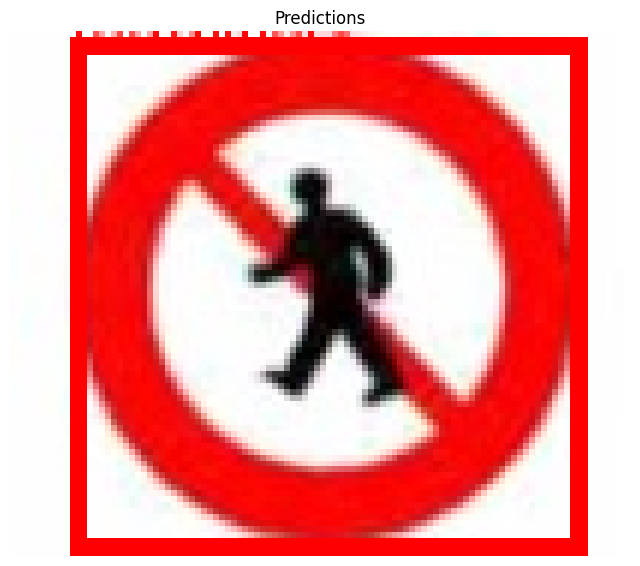

[{'x': 53.22425079345703,
  'y': 44.359129190444946,
  'width': 86.15223693847656,
  'height': 85.32931852340698,
  'confidence': 0.8643764853477478,
  'class': 'regulatory',
  'class_id': 4,
  'detection_id': '5d8459bb-b099-4b09-b693-f4e2dac6fd86'}]

In [ ]:
# idx = 4
predictions = pipeline.detect(
    input_path / traffic_sign_descriptions[idx]["images"][0]
)
plot_prediction_boxes(
    image_path=input_path / traffic_sign_descriptions[idx]["images"][0],
    predictions=predictions
)
idx += 1
predictions

In [ ]:
import os
import json
import torch
from PIL import Image
from tqdm.notebook import tqdm
from pathlib import Path

image_folder = Path("./data/processed/law_db/images")
device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device)

# Load metadata
with open('./data/processed/law_db/articles/traffic_sign_description.json') as f:
    traffic_sign_description = json.load(f)

sign_image_paths = []
image_filenames = []

# Collect image paths and filenames
for desc in traffic_sign_description:
    image_filenames.extend(desc["images"])
    sign_image_paths.extend([image_folder / filename for filename in desc["images"]])

# Parameters
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

all_image_features = []

with torch.no_grad():
    for i in tqdm(range(0, len(sign_image_paths), batch_size)):
        batch_paths = sign_image_paths[i:i + batch_size]
        batch_images = [Image.open(p).convert("RGB") for p in batch_paths]
        # Preprocess
        inputs = processor(images=batch_images, return_tensors="pt").to(device)

        # Get features
        outputs = model(**inputs)
        batch_features = outputs.last_hidden_state[:, 0, :]
        all_image_features.append(batch_features)

# Concatenate all features
image_features = torch.cat(all_image_features, dim=0)

In [13]:
import json
import faiss
import torch
import numpy as np
from PIL import Image

# # Assume you already have vector_db list from before
# embeddings = image_features.to('cpu', dtype=torch.float32).numpy()

# # Build a simple index using L2 distance
# index = faiss.IndexFlatL2(embeddings.shape[1])
# index.add(embeddings)

# # Save index to disk
# faiss.write_index(index, "./assets/image_index.faiss")

index = faiss.read_index("./assets/image_index.faiss")

# Later when retrieving
index_to_image = image_filenames  # or sign_image_paths

def query_image(query_image_path, top_k=5):
    # Load and preprocess
    query_image = Image.open(query_image_path).convert("RGB")
    inputs = processor(images=query_image, return_tensors="pt").to(device)

    with torch.no_grad():
        query_features = model(**inputs).last_hidden_state[:, 0, :].cpu().numpy()
    # Search top-k
    distances, indices = index.search(query_features, top_k)

    print("Top results:")
    for i, idx in enumerate(indices[0]):
        print(f"{i+1}. {index_to_image[idx]} (Distance: {distances[0][i]:.4f})")



In [1]:
%cd ..

c:\Users\Tuan Kiet\Desktop\Workspace\VLSP_2025_SIGMA


In [2]:
from src.services import get_service

service = get_service()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


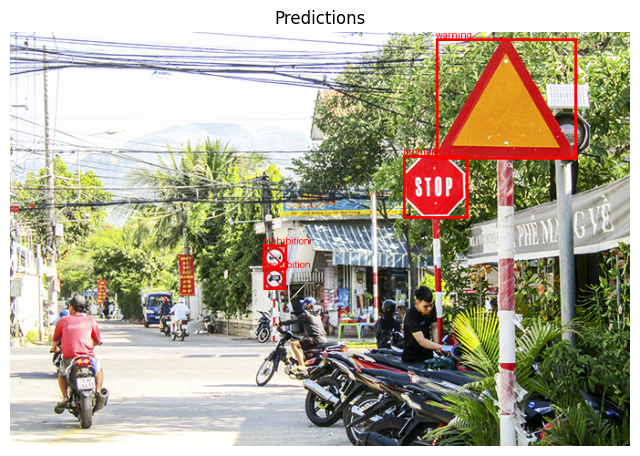

In [3]:
from src.utils.crop_utils import plot_prediction_boxes
predictions = service.detector.detect(
    image=r"data\train_data\train_images\train_images\train_1_1.jpg"
)

plot_prediction_boxes(
    image=r"data\train_data\train_images\train_images\train_1_1.jpg",
    predictions=predictions
)

In [5]:
from PIL import Image

image = Image.open(r"data\processed\law_db\images\image003.png").convert("RGB")

service.image_retriever.search(image)

  0%|          | 0/1 [00:00<?, ?it/s]

[{'filename': 'image468.jpg', 'score': 22.8911075592041},
 {'filename': 'image464.jpg', 'score': 21.538301467895508},
 {'filename': 'image466.jpg', 'score': 19.50743865966797},
 {'filename': 'image478.jpg', 'score': 18.81566047668457},
 {'filename': 'image496.jpg', 'score': 15.478103637695312}]